# **Variational Quantum Eigensolver**
---
<img src="Imperial_logo.png" align = "left" width=200>
 <br>
 
- Copyright (c) Jack Jacquier, 2026. All rights reserved

- Author: Jack Jacquier <a.jacquier@imperial.ac.uk>

- Platform: Tested on Windows 10 with Python 3.9

In [1]:
import numpy as np
from random import random
from scipy.optimize import minimize
import matplotlib.pylab as plt

from numpy import linalg as LA

from qiskit import QuantumCircuit
from qiskit_aer import Aer

## Generating a Hamiltonian from Pauli operators

We generate a Hamiltonian of the form
$$
\mathcal{H} = \alpha_{\mathtt{I}}\mathtt{I} + \alpha_{\mathtt{X}}\mathtt{X} + \alpha_{\mathtt{Y}}\mathtt{Y} + \alpha_{\mathtt{Z}}\mathtt{Z},
$$
where the coefficients are picked randomly.

In [2]:
def matprint(mat, fmt="g"):
    ## Just to print a matrix nicely
    col_maxes = [max([len(("{:"+fmt+"}").format(x)) for x in col]) for col in mat.T]
    for x in mat:
        for i, y in enumerate(x):
            print(("{:"+str(col_maxes[i])+fmt+"}").format(y), end="  ")
        print("")

In [3]:
GATE_NAMES = ["I", "Z", "X", "Y"]

In [4]:
coefficients = 3.*np.random.rand(len(GATE_NAMES))

In [5]:
hamiltonian = {}
for (i,g) in enumerate(GATE_NAMES):
    hamiltonian[g] = coefficients[i]

In [6]:
print("Pauli decomposition of the matrix: ")
for gate_name in hamiltonian:
    print(gate_name, ": ", hamiltonian[gate_name])

Pauli decomposition of the matrix: 
I :  2.1741253298347325
Z :  1.0199549898480758
X :  2.865536723812303
Y :  1.4513521916061083


### Matrix representation

We use the matrix representation for the Pauli gates
$\mathtt{I}, \mathtt{X}, \mathtt{Y}, \mathtt{Z}$ and deduce one for the Hamiltonian $\mathcal{H}$ defined above.


In [7]:
pauli_matrices = {"I": np.array([[1., 0.],[0., 1.]]),
                  "Z": np.array([[1., 0.],[0., -1.]]),
                  "X": np.array([[0., 1.],[1., 0.]]),
                  "Y": np.array([[0., -1j],[1j, 0.]])
                 }

H_matrix = np.zeros((2,2))

for g in GATE_NAMES:
    H_matrix = H_matrix + hamiltonian[g]*pauli_matrices[g]

print("The 2*2 matrix representation of the Hamiltonian is")
matprint(H_matrix)

The 2*2 matrix representation of the Hamiltonian is
      3.19408+0j  2.86554-1.45135j  
2.86554+1.45135j        1.15417+0j  


In [8]:
eigenpairs = LA.eig(H_matrix)
for i in range(len(eigenpairs)):
    print("Eigenpair: ", np.round(eigenpairs[0][i], 4), np.round(eigenpairs[1][i], 4))

Eigenpair:  (5.5443-0j) [ 0.807 +0.j     -0.5268+0.2668j]
Eigenpair:  (-1.196+0j) [0.5268+0.2668j 0.807 +0.j    ]


In [9]:
classical_min_eigenvalue = np.min(eigenpairs[0].real)
print("Minimum eigenvalue: ", classical_min_eigenvalue)

Minimum eigenvalue:  -1.1960426305068275


# TEST VQE

Recall that any vector in $\mathbb{C}^2$, viewed as a one-qubit quantum state, can be written as
$$
|\psi\rangle = \begin{pmatrix}
\cos\left(\frac{\theta}{2}\right)\\
\mathrm{e}^{\mathrm{i}\varphi}\sin\left(\frac{\theta}{2}\right)\\
\end{pmatrix},
$$
for some $\varphi, \theta \in \mathbb{R}$.
Now, with the rotation matrices
$$
R_{\mathtt{X}}(\theta) := 
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right) & -\mathrm{i}\sin\left(\frac{\theta}{2}\right)\\
-\mathrm{i}\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}
\qquad\text{and}\qquad
R_{\mathtt{Y}}(\theta) := 
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right)\\
\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix},
$$
we know that we can find $\theta_0, \theta_1$ such that
$$
|\psi\rangle = R_{\mathtt{Y}}(\theta_1)R_{\mathtt{X}}(\theta_0)|0\rangle.
$$

Note that the general `qiskit` U gate is defined as
$$
U(\theta, \phi, \lambda) := 
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right) & -\mathrm{e}^{\mathrm{i}\lambda}\sin\left(\frac{\theta}{2}\right)\\
\mathrm{e}^{\mathrm{i}\phi}\sin\left(\frac{\theta}{2}\right) & \mathrm{e}^{\mathrm{i}(\phi+\lambda)}\cos\left(\frac{\theta}{2}\right)
\end{pmatrix}.
$$
In particular, 
$$
U\left(\frac{\pi}{2}, 0, \pi\right) = \mathrm{H} = \frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}
\qquad\text{and}\qquad
U\left(\frac{\pi}{2}, 0, \frac{\pi}{2}\right) = \mathrm{G} = \frac{1}{\sqrt{2}}\begin{pmatrix}1&-\mathrm{i}\\1&\mathrm{i}\end{pmatrix}.
$$

In [10]:
def param_qc(thetas, gate_name):
    """
    Ansatz circuit for the optimization
    thetas: parameters for the rotation gates
    gate_name: Pauli gate
    returns a quantum circuit.
    """

    qc = QuantumCircuit(1)

    ## create a general one-qubit quantum state (using the two rotations matrices above)
    qc.rx(thetas[0], 0)
    qc.ry(thetas[1], 0)

    ## Add an extra gate
    if gate_name == 'X':
        qc.h(0)
        
    elif gate_name == 'Y':
        qc.u(.5*np.pi, 0, .5*np.pi, 0) ## Corresponds to the G gate

    qc.measure_all()
    return qc

In [11]:
def quantum_expectation(thetas, gate_name, nbShots):
    # measure
    if gate_name == 'I':
        return 1
    else:
        qc = param_qc(thetas, gate_name)
    
    nbShots
    backend = Aer.get_backend('qasm_simulator')
    result = backend.run(qc, shots=nbShots).result()
    counts = result.get_counts()

    expectation = 0
    for c in counts:
        sign = +1
        
        if c == '1':
            sign = -1
        expectation += sign * counts[c] / nbShots
        
    return expectation

In [12]:
def vqe(thetas, args):
    """
    Generates |psi(thetas)>
    Computes the expectation <psi(thetas) | H | psi(thetas)>
    """
    args = hamiltonian, GATE_NAMES, nbShots
    total_expectation = 0.
    
    for gatename in GATE_NAMES:
        weight_gate = 0.
        for k in hamiltonian.keys():
            if k == gatename:
                weight_gate = hamiltonian[k]
        total_expectation += weight_gate * quantum_expectation(thetas, gatename, nbShots)

    return total_expectation

In [13]:
### Define a starting point for the vector of parameters [theta[0], theta[1]]
thetas = np.random.rand(2)*np.pi
print("Starting parameter points: ", thetas)
nbShots = 20000

vqe_result = minimize(vqe, thetas, args=[hamiltonian, GATE_NAMES, nbShots], method="Nelder-Mead", tol=1e-20)

Starting parameter points:  [1.16095469 1.2664771 ]


In [14]:
vvv = vqe(thetas, args=[hamiltonian, GATE_NAMES, nbShots])
print('Starting VQE state energy:', vvv)
print('Optimal parameters theta:', vqe_result.x)
print('VQE ground state energy  %.4f' %vqe_result.fun)
print('Classical ground state energy  %.4f' %classical_min_eigenvalue)

Starting VQE state energy: 2.0718259584649372
Optimal parameters theta: [2.69831266 1.1097757 ]
VQE ground state energy  -1.2365
Classical ground state energy  -1.1960


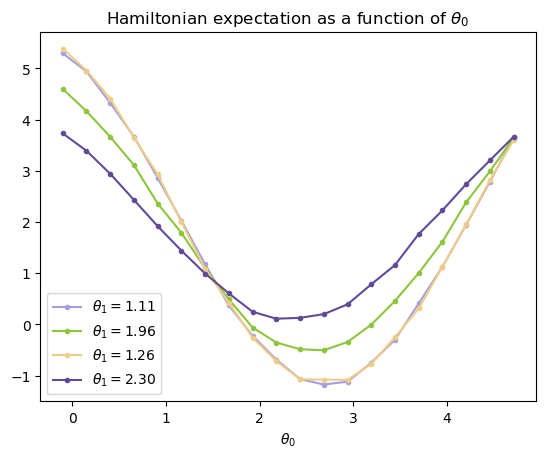

In [15]:
nbShots = 5000
M = 20
tt = np.linspace(-0.1, 1.5*np.pi, M)
N = 4
theta1 = np.random.rand(N)*np.pi
theta1[0] = vqe_result.x[1]
currentVal = np.zeros((N, M))
mycolors = np.random.rand(N,3)
arguments = hamiltonian, GATE_NAMES, nbShots

for k in range(M):
    for i in range(N):
        currentVal[i,k] = vqe(np.array([tt[k], theta1[i]]), arguments)

for i in range(N):
    plt.plot(tt, currentVal[i,:], c=mycolors[i], marker='.', label=r'$\theta_1=$%.2f' %theta1[i])

plt.title(r'Hamiltonian expectation as a function of $\theta_0$')
plt.xlabel(r'$\theta_{0}$')
plt.legend(loc="best")
plt.show()

### Checking the output

$$
\mathtt{R}_{\mathtt{X}}(\theta) := 
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right) & -\mathrm{i}\sin\left(\frac{\theta}{2}\right)\\
-\mathrm{i}\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix}
\qquad\text{and}\qquad
\mathtt{R}_{\mathtt{Y}}(\theta) := 
\begin{pmatrix}
\cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right)\\
\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right)
\end{pmatrix},
$$

$$
\mathtt{R}\left(\frac{\pi}{2}, 0, \pi\right) = \mathrm{H} = \frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}
\qquad\text{and}\qquad
\mathtt{R}\left(\frac{\pi}{2}, 0, \frac{\pi}{2}\right) = \mathrm{G} = \frac{1}{\sqrt{2}}\begin{pmatrix}1&-\mathrm{i}\\1&\mathrm{i}\end{pmatrix}.
$$

#### Vector of parameters $(\theta_0, \theta_1)$:

In [16]:
print("Optimal vector of parameters: ", vqe_result.x)

Optimal vector of parameters:  [2.69831266 1.1097757 ]
